<a href="https://colab.research.google.com/github/aadyajhab09002/Closet-Connect/blob/main/PINN_for_FISHER_KPP_Equation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [2]:
import torch.nn as nn

class PINN(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(2,50),
            nn.Tanh(),

            nn.Linear(50,50),
            nn.Tanh(),

            nn.Linear(50,50),
            nn.Tanh(),

            nn.Linear(50,50),
            nn.Tanh(),

            nn.Linear(50,50),
            nn.Tanh(),

            nn.Linear(50,50),
            nn.Tanh(),

            nn.Linear(50,50),
            nn.Tanh(),

            nn.Linear(50,1)

        )

    def forward(self,x,t):

        inputs = torch.cat([x,t],dim=1)

        return self.network(inputs)

In [3]:
# ============================================================
# STEP 2 & 3: Neural Network Architecture
# ============================================================
# Install/import all necessary libraries for the entire project
# Run this cell first in Google Colab

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import cm
import time

# ── Reproducibility ──────────────────────────────────────────
# Setting seeds ensures you get the same result every run.
# Neural networks are initialized randomly; fixing the seed
# makes your experiments reproducible — important for a paper.
torch.manual_seed(42)
np.random.seed(42)

# ── Device configuration ──────────────────────────────────────
# PINNs benefit greatly from GPU acceleration.
# torch.cuda.is_available() returns True if a GPU is detected.
# In Colab: Runtime → Change runtime type → GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
# Expected output: "Using device: cuda"  (if GPU is enabled in Colab)
# or              "Using device: cpu"

# ============================================================
# The PINN Neural Network Class
# ============================================================

class FisherKPP_PINN(nn.Module):
    """
    Physics-Informed Neural Network for the Fisher-KPP equation.

    Architecture:
        Input  layer : 2 neurons  (x, t)
        Hidden layers: 7 × 50 neurons with Tanh activation
        Output layer : 1 neuron   (u)

    This class inherits from nn.Module, which is PyTorch's
    base class for ALL neural networks. Every custom network
    in PyTorch must inherit from nn.Module.
    """

    def __init__(self):
        """
        __init__ is called when you create an instance of the class.
        Here we DEFINE the architecture (layers).
        """

        # Always call the parent class constructor first.
        # This initializes internal PyTorch bookkeeping.
        super(FisherKPP_PINN, self).__init__()

        # ── Store architecture hyperparameters ────────────────
        # These are fixed design choices, not learned parameters.
        self.input_dim  = 2    # (x, t)
        self.hidden_dim = 50   # neurons per hidden layer
        self.output_dim = 1    # u(x,t)
        self.num_hidden = 7    # number of hidden layers

        # ── Build the network using nn.ModuleList ─────────────
        # nn.ModuleList is like a Python list, but PyTorch
        # can "see" all the layers inside it and track their
        # parameters automatically.
        self.layers = nn.ModuleList()

        # Input layer: maps (x,t) → 50 neurons
        # nn.Linear(in_features, out_features) creates one
        # fully-connected layer: z = W·x + b
        self.layers.append(nn.Linear(self.input_dim, self.hidden_dim))

        # Hidden layers: 6 more layers of 50 → 50
        # (Together with the input layer above, this gives
        #  7 hidden layers total)
        for _ in range(self.num_hidden - 1):
            self.layers.append(nn.Linear(self.hidden_dim, self.hidden_dim))

        # Output layer: 50 → 1  (NO activation function here)
        # We want the output to be unbounded so the network
        # can represent any value of u.
        self.output_layer = nn.Linear(self.hidden_dim, self.output_dim)

        # ── Activation function ───────────────────────────────
        # torch.tanh will be applied after every hidden layer.
        # We don't create a separate layer for it; we just
        # call torch.tanh() in the forward pass.

        # ── Initialize weights using Xavier uniform ───────────
        self._initialize_weights()

    def _initialize_weights(self):
        """
        Apply Xavier (Glorot) uniform initialization to all
        weight matrices, and set all biases to zero.

        Why Xavier?
        -----------
        If weights are too large  → activations saturate (tanh → ±1)
                                  → gradients vanish
        If weights are too small  → activations near zero
                                  → network learns slowly

        Xavier sets W ~ Uniform(-a, +a) where
            a = sqrt(6 / (fan_in + fan_out))
        This keeps the variance of the output of each layer
        roughly equal to the variance of its input.
        """
        for layer in self.layers:
            # nn.init.xavier_uniform_ applies the initialization
            # in-place (the underscore suffix means in-place).
            # layer.weight is the weight matrix W.
            nn.init.xavier_uniform_(layer.weight,
                                    gain=nn.init.calculate_gain('tanh'))
            # Initialize all biases to zero.
            # layer.bias is the bias vector b.
            nn.init.zeros_(layer.bias)

        # Also initialize the output layer
        nn.init.xavier_uniform_(self.output_layer.weight,
                                gain=nn.init.calculate_gain('tanh'))
        nn.init.zeros_(self.output_layer.bias)

    def forward(self, x, t):
        """
        The forward pass defines HOW data flows through the network.
        PyTorch calls this automatically when you do: model(x, t)

        Parameters
        ----------
        x : torch.Tensor, shape [N, 1]
            Spatial coordinates
        t : torch.Tensor, shape [N, 1]
            Time coordinates

        Returns
        -------
        u : torch.Tensor, shape [N, 1]
            Predicted solution u(x,t)
        """

        # ── Concatenate inputs along dimension 1 ─────────────
        # x has shape [N, 1], t has shape [N, 1]
        # torch.cat(..., dim=1) stacks them column-wise
        # Result: inp has shape [N, 2]
        # Each row is one (x, t) point.
        inp = torch.cat([x, t], dim=1)

        # ── Pass through hidden layers ────────────────────────
        # 'out' starts as the concatenated input.
        # Each iteration applies: out = tanh(W·out + b)
        out = inp
        for layer in self.layers:
            # layer(out) computes W·out + b  (the linear part)
            # torch.tanh(...) applies the activation function
            out = torch.tanh(layer(out))

        # ── Output layer (NO activation) ──────────────────────
        # Final linear transformation: u = W·out + b
        # No tanh here — the output should be unconstrained.
        u = self.output_layer(out)

        return u  # shape: [N, 1]

    def count_parameters(self):
        """
        Utility: count total trainable parameters.
        Useful to report in your paper.
        """
        return sum(p.numel() for p in self.parameters()
                   if p.requires_grad)


# ============================================================
# Instantiate and inspect the network
# ============================================================

# Create the model and move it to GPU (if available)
model = FisherKPP_PINN().to(device)

# Print the architecture
print("=" * 55)
print("       PINN Architecture for Fisher-KPP Equation")
print("=" * 55)
print(model)
print("=" * 55)
print(f"Total trainable parameters: {model.count_parameters():,}")
print("=" * 55)

Using device: cuda
       PINN Architecture for Fisher-KPP Equation
FisherKPP_PINN(
  (layers): ModuleList(
    (0): Linear(in_features=2, out_features=50, bias=True)
    (1-6): 6 x Linear(in_features=50, out_features=50, bias=True)
  )
  (output_layer): Linear(in_features=50, out_features=1, bias=True)
)
Total trainable parameters: 15,501


In [4]:
# ============================================================
# STEP 4: Evaluate the network at a single point
# ============================================================

# Create a single test point (x=0.5, t=0.3)
# torch.tensor() creates a tensor from a Python number.
# dtype=torch.float32: use 32-bit floats (standard for NNs)
# .to(device): move the tensor to GPU if available

x_test = torch.tensor([[0.5]], dtype=torch.float32).to(device)
t_test = torch.tensor([[0.3]], dtype=torch.float32).to(device)

# Shape check — always important!
print(f"x_test shape: {x_test.shape}")   # Should be [1, 1]
print(f"t_test shape: {t_test.shape}")   # Should be [1, 1]

# ── Forward pass ──────────────────────────────────────────────
# model.eval() tells PyTorch we are in evaluation mode
# (turns off dropout, batch norm if present — good practice)
model.eval()

# torch.no_grad(): do NOT build a computation graph.
# We use this when we only want the output, not derivatives.
# This saves memory and speeds up evaluation.
with torch.no_grad():
    u_pred = model(x_test, t_test)

print(f"\nNetwork output at (x=0.5, t=0.3): {u_pred.item():.6f}")
# Note: .item() converts a 1-element tensor to a Python scalar

# ── Evaluate on a batch of points ────────────────────────────
# In practice we evaluate thousands of points simultaneously.
# This is much faster than a loop (GPU parallelism).

N_test = 5
x_batch = torch.linspace(0, 1, N_test).reshape(-1, 1).to(device)
t_batch = torch.full((N_test, 1), 0.3).to(device)
# torch.linspace(0,1,5) = [0, 0.25, 0.5, 0.75, 1.0]
# .reshape(-1, 1) converts shape [5] → [5, 1]
# torch.full((5,1), 0.3) creates a tensor of all 0.3s

with torch.no_grad():
    u_batch = model(x_batch, t_batch)

print(f"\nBatch evaluation at t=0.3, x in [0,1]:")
print(f"{'x':>8}  {'û(x,0.3)':>12}")
print("-" * 22)
for i in range(N_test):
    print(f"{x_batch[i].item():>8.4f}  {u_batch[i].item():>12.6f}")

x_test shape: torch.Size([1, 1])
t_test shape: torch.Size([1, 1])

Network output at (x=0.5, t=0.3): 0.249883

Batch evaluation at t=0.3, x in [0,1]:
       x      û(x,0.3)
----------------------
  0.0000      0.243709
  0.2500      0.178088
  0.5000      0.249883
  0.7500      0.382118
  1.0000      0.511392


In [5]:
# ============================================================
# STEP 5 & 6: Automatic Differentiation
# ============================================================

def compute_derivatives(model, x, t, D, r):
    """
    Compute all derivatives needed for the Fisher-KPP PDE:
        u_t  = ∂u/∂t
        u_x  = ∂u/∂x
        u_xx = ∂²u/∂x²

    And also compute the PDE residual:
        f = u_t - D·u_xx - r·u·(1-u)

    Parameters
    ----------
    model : FisherKPP_PINN
        The neural network
    x : torch.Tensor, shape [N, 1], requires_grad=True
        Spatial coordinates (must have grad enabled)
    t : torch.Tensor, shape [N, 1], requires_grad=True
        Time coordinates (must have grad enabled)
    D : float
        Diffusion coefficient
    r : float
        Growth rate

    Returns
    -------
    u     : predicted solution, shape [N, 1]
    u_t   : ∂u/∂t,             shape [N, 1]
    u_xx  : ∂²u/∂x²,           shape [N, 1]
    f     : PDE residual,       shape [N, 1]
    """

    # ── Forward pass ──────────────────────────────────────────
    # Compute û(x,t) through the network.
    # Because x and t have requires_grad=True, PyTorch
    # builds the full computation graph including x and t.
    u = model(x, t)
    # u shape: [N, 1]

    # ── First derivatives ─────────────────────────────────────
    # torch.autograd.grad(outputs, inputs, grad_outputs, ...)
    #
    # outputs      : the function we are differentiating (u)
    # inputs       : what we differentiate WITH RESPECT TO (x, t)
    # grad_outputs : "upstream gradient" — for scalar loss it's 1,
    #                for tensor outputs we use torch.ones_like(u)
    #                This is equivalent to computing ∑ ∂u_i/∂x_i
    #                for each element, which gives us element-wise
    #                ∂u/∂x for every point in the batch.
    # create_graph : True  → build graph FOR the gradient itself
    #                        (needed to differentiate u_x → u_xx)
    # retain_graph : True  → keep the original graph so we can
    #                        differentiate u with respect to t too

    # Compute ∂u/∂x and ∂u/∂t simultaneously
    grads = torch.autograd.grad(
        outputs=u,
        inputs=[x, t],
        grad_outputs=torch.ones_like(u),
        create_graph=True,   # MUST be True for u_xx
        retain_graph=True    # Keep graph for second call
    )
    # grads is a tuple: (∂u/∂x,  ∂u/∂t)
    u_x = grads[0]   # shape: [N, 1]
    u_t = grads[1]   # shape: [N, 1]

    # ── Second derivative ─────────────────────────────────────
    # Now differentiate u_x with respect to x again.
    # This gives us ∂(∂u/∂x)/∂x = ∂²u/∂x²
    #
    # Note: create_graph=True was required in the step above
    # so that u_x itself has a computation graph to differentiate.
    u_xx = torch.autograd.grad(
        outputs=u_x,
        inputs=x,
        grad_outputs=torch.ones_like(u_x),
        create_graph=True    # True if we need higher derivatives
    )[0]
    # [0] because grad returns a tuple; we only asked for d/dx
    # u_xx shape: [N, 1]

    return u, u_t, u_x, u_xx


# ── Test the derivative computation ──────────────────────────
# We use a known function to verify autograd is working.
# Let's test with f(x,t) = sin(πx)·cos(πt)
# Analytical derivatives:
#   f_x  = π·cos(πx)·cos(πt)
#   f_xx = -π²·sin(πx)·cos(πt)
#   f_t  = -π·sin(πx)·sin(πt)

print("Testing autograd on a known function...")
print("(This verifies our derivative code is correct)\n")

# Create test points with requires_grad=True
# This is the crucial flag — without it, autograd won't work!
x_verify = torch.linspace(0, 1, 5).reshape(-1, 1).to(device)
t_verify = torch.full((5, 1), 0.3).to(device)

# Clone and enable gradients
x_v = x_verify.clone().requires_grad_(True)
t_v = t_verify.clone().requires_grad_(True)

# Compute u = sin(πx)·cos(πt) and its derivatives
import math
u_v   = torch.sin(math.pi * x_v) * torch.cos(math.pi * t_v)

grads = torch.autograd.grad(
    outputs=u_v,
    inputs=[x_v, t_v],
    grad_outputs=torch.ones_like(u_v),
    create_graph=True,
    retain_graph=True
)
u_x_v = grads[0]
u_t_v = grads[1]

u_xx_v = torch.autograd.grad(
    outputs=u_x_v,
    inputs=x_v,
    grad_outputs=torch.ones_like(u_x_v),
    create_graph=True
)[0]

# Analytical values
u_x_analytical  =  math.pi * torch.cos(math.pi * x_v) * torch.cos(math.pi * t_v)
u_xx_analytical = -math.pi**2 * torch.sin(math.pi * x_v) * torch.cos(math.pi * t_v)
u_t_analytical  = -math.pi * torch.sin(math.pi * x_v) * torch.sin(math.pi * t_v)

print(f"{'x':>6} | {'u_x (auto)':>12} | {'u_x (exact)':>12} | {'u_xx (auto)':>12} | {'u_xx (exact)':>12}")
print("-" * 65)
for i in range(5):
    print(f"{x_v[i].item():>6.3f} | "
          f"{u_x_v[i].item():>12.6f} | "
          f"{u_x_analytical[i].item():>12.6f} | "
          f"{u_xx_v[i].item():>12.6f} | "
          f"{u_xx_analytical[i].item():>12.6f}")

print("\n✓ Autograd matches analytical derivatives perfectly!")
print("  (Any difference should be < 1e-6, i.e., machine precision)")

Testing autograd on a known function...
(This verifies our derivative code is correct)

     x |   u_x (auto) |  u_x (exact) |  u_xx (auto) | u_xx (exact)
-----------------------------------------------------------------
 0.000 |     1.846582 |     1.846582 |    -0.000000 |    -0.000000
 0.250 |     1.305730 |     1.305730 |    -4.102074 |    -4.102073
 0.500 |    -0.000000 |    -0.000000 |    -5.801208 |    -5.801207
 0.750 |    -1.305730 |    -1.305730 |    -4.102074 |    -4.102073
 1.000 |    -1.846582 |    -1.846582 |     0.000001 |     0.000001

✓ Autograd matches analytical derivatives perfectly!
  (Any difference should be < 1e-6, i.e., machine precision)


In [6]:
# ============================================================
# STEP 7: PDE Residual for Fisher-KPP
# ============================================================

# ── PDE parameters ────────────────────────────────────────────
# These values will be used throughout.
D = 0.001   # Diffusion coefficient
r = 1.0     # Growth rate
# These are standard benchmark values in the PINN literature
# for Fisher-KPP. Small D means the wave front is sharp.

def pde_residual(model, x, t, D, r):
    """
    Compute the Fisher-KPP PDE residual at collocation points.

    Residual:  f = u_t - D·u_xx - r·u·(1-u)

    A well-trained PINN should produce f ≈ 0 everywhere
    in the domain.

    Parameters
    ----------
    model : FisherKPP_PINN
    x     : torch.Tensor [N, 1], requires_grad=True
    t     : torch.Tensor [N, 1], requires_grad=True
    D     : float, diffusion coefficient
    r     : float, growth rate

    Returns
    -------
    u : torch.Tensor [N, 1], predicted solution
    f : torch.Tensor [N, 1], PDE residual (should → 0)
    """

    # Get u and all its derivatives
    u, u_t, u_x, u_xx = compute_derivatives(model, x, t, D, r)

    # Compute the nonlinear reaction term: r·u·(1-u)
    # This is element-wise multiplication in PyTorch.
    reaction = r * u * (1.0 - u)

    # Assemble the PDE residual
    # If the PDE is satisfied: u_t = D·u_xx + r·u·(1-u)
    # Rearranged: u_t - D·u_xx - r·u·(1-u) = 0
    f = u_t - D * u_xx - reaction

    return u, f


# ── Quick sanity check ────────────────────────────────────────
# Create a small batch of points
N_test = 10
x_test_pde = torch.rand(N_test, 1).to(device).requires_grad_(True)
t_test_pde = torch.rand(N_test, 1).to(device).requires_grad_(True)

# Run a forward pass to compute the residual
model.train()  # switch back to training mode
u_test, f_test = pde_residual(model, x_test_pde, t_test_pde, D, r)

print(f"PDE residual shape: {f_test.shape}")
print(f"Mean |residual| before training: {f_test.abs().mean().item():.4f}")
print(f"(This is large — network is untrained. After training it should be ≈ 0)")
print(f"\nu prediction range: [{u_test.min().item():.4f}, {u_test.max().item():.4f}]")

PDE residual shape: torch.Size([10, 1])
Mean |residual| before training: 0.7469
(This is large — network is untrained. After training it should be ≈ 0)

u prediction range: [-0.1992, 0.5467]


In [7]:
# ============================================================
# STEP 8: Generate Training Points
# ============================================================

# ── Problem domain ────────────────────────────────────────────
x_min, x_max = 0.0, 1.0   # spatial domain
t_min, t_max = 0.0, 1.0   # temporal domain

# ── PDE parameters (same as before) ──────────────────────────
D = 0.001
r = 1.0

# ── Number of training points ─────────────────────────────────
N_pde = 10000   # collocation points (interior)
N_ic  = 200     # initial condition points
N_bc  = 200     # boundary condition points (100 per boundary)

# ═══════════════════════════════════════════════════════════════
# EXACT SOLUTION — Fisher-KPP Traveling Wave
# ═══════════════════════════════════════════════════════════════
# The Fisher-KPP equation has an analytical traveling wave
# solution of the form:
#
#   u(x, t) = [1 + exp(k·(x - v·t - x₀))]^(-2)
#
# where:
#   v = 5/√(6D/r) · √(Dr) = (5/√6)·√(D·r)  — wave speed
#
# Exact analytical solution used in Ablowitz & Zeppetella (1979):
#   u(x, t) = 1 / (1 + C·exp(k·(x - v·t)))²
#
# with:
#   k = √(r / (6D))  — spatial decay rate
#   v = 5√(Dr/6)     — wave speed (this is the special case
#                       where the exact solution is known)
#   C = arbitrary (we use 1 for symmetry)
#   x₀ = 0.5        — initial wave center

def exact_solution(x, t, D, r):
    """
    Exact traveling wave solution to the Fisher-KPP equation.

    u(x,t) = 1 / (1 + exp(k*(x - v*t - x0)))^2

    Valid for the special wave speed v = 5*sqrt(D*r/6).

    Parameters
    ----------
    x, t : numpy arrays or torch tensors
    D    : diffusion coefficient
    r    : growth rate

    Returns
    -------
    u : exact solution, same type as x
    """
    # Wave parameters
    k  = np.sqrt(r / (6.0 * D))    # spatial wave number
    v  = 5.0 * np.sqrt(D * r / 6.0) # wave speed
    x0 = 0.5                         # initial position of wave front

    # Traveling wave solution (Ablowitz-Zeppetella)
    # The (1 + exp(...))^(-2) form is the exact solution
    exponent = k * (x - v * t - x0)
    u = 1.0 / (1.0 + np.exp(exponent))**2

    return u

# Print wave parameters
k_val = np.sqrt(r / (6.0 * D))
v_val = 5.0 * np.sqrt(D * r / 6.0)
print("=" * 50)
print("Fisher-KPP Traveling Wave Parameters")
print("=" * 50)
print(f"  Diffusion D = {D}")
print(f"  Growth    r = {r}")
print(f"  Wave number k = √(r/6D) = {k_val:.4f}")
print(f"  Wave speed  v = 5√(Dr/6) = {v_val:.4f}")
print(f"  [Wave moves from left to right]")
print("=" * 50)


# ═══════════════════════════════════════════════════════════════
# 1. COLLOCATION POINTS — Interior of domain
# ═══════════════════════════════════════════════════════════════
# These are points where we enforce the PDE residual = 0.
# We use Latin Hypercube Sampling (LHS) for better coverage.
# For simplicity here we use uniform random sampling.
#
# Domain: x ∈ [0,1], t ∈ [0,1]
# We MUST set requires_grad=True because we will differentiate
# the network output with respect to x and t at these points.

np.random.seed(42)

# Random sampling in the interior
x_pde_np = np.random.uniform(x_min, x_max, (N_pde, 1))
t_pde_np = np.random.uniform(t_min, t_max, (N_pde, 1))

# Convert to PyTorch tensors on the correct device
# requires_grad=True is CRITICAL — autograd needs this!
x_pde = torch.tensor(x_pde_np, dtype=torch.float32).to(device).requires_grad_(True)
t_pde = torch.tensor(t_pde_np, dtype=torch.float32).to(device).requires_grad_(True)

print(f"\n1. Collocation points (PDE residual):")
print(f"   Shape: x_pde {x_pde.shape}, t_pde {t_pde.shape}")
print(f"   x range: [{x_pde_np.min():.3f}, {x_pde_np.max():.3f}]")
print(f"   t range: [{t_pde_np.min():.3f}, {t_pde_np.max():.3f}]")
print(f"   requires_grad: {x_pde.requires_grad}")


# ═══════════════════════════════════════════════════════════════
# 2. INITIAL CONDITION POINTS — t = 0
# ═══════════════════════════════════════════════════════════════
# At t=0, we know the exact solution: u(x,0) = u_0(x)
# The network must match this exactly.

x_ic_np = np.linspace(x_min, x_max, N_ic).reshape(-1, 1)
t_ic_np = np.zeros((N_ic, 1))   # t = 0

# Compute the exact initial condition
u_ic_np = exact_solution(x_ic_np, t_ic_np, D, r)

# Convert to tensors
# Note: IC/BC points do NOT need requires_grad
# (we don't differentiate through them for the IC/BC loss)
x_ic = torch.tensor(x_ic_np, dtype=torch.float32).to(device)
t_ic = torch.tensor(t_ic_np, dtype=torch.float32).to(device)
u_ic = torch.tensor(u_ic_np, dtype=torch.float32).to(device)

print(f"\n2. Initial condition points (t = 0):")
print(f"   Shape: x_ic {x_ic.shape}, u_ic {u_ic.shape}")
print(f"   u_IC range: [{u_ic_np.min():.4f}, {u_ic_np.max():.4f}]")
print(f"   (Should be close to traveling wave at t=0)")


# ═══════════════════════════════════════════════════════════════
# 3. BOUNDARY CONDITION POINTS — x = 0 and x = 1
# ═══════════════════════════════════════════════════════════════
# At the spatial boundaries, we enforce the exact solution
# (Dirichlet boundary conditions).
#
# Left boundary  (x=0): u(0,t) = exact_solution(0, t)
# Right boundary (x=1): u(1,t) = exact_solution(1, t)
#
# We use the exact traveling wave solution as BC.
# This is more accurate than fixed 0/1 BCs.

N_bc_each = N_bc // 2   # 100 points per boundary

t_bc_np = np.linspace(t_min, t_max, N_bc_each).reshape(-1, 1)

# Left boundary: x = 0
x_bc_left_np  = np.zeros((N_bc_each, 1))
u_bc_left_np  = exact_solution(x_bc_left_np, t_bc_np, D, r)

# Right boundary: x = 1
x_bc_right_np = np.ones((N_bc_each, 1))
u_bc_right_np = exact_solution(x_bc_right_np, t_bc_np, D, r)

# Concatenate left and right
x_bc_np = np.vstack([x_bc_left_np,  x_bc_right_np])   # [N_bc, 1]
t_bc_np_all = np.vstack([t_bc_np, t_bc_np])            # [N_bc, 1]
u_bc_np = np.vstack([u_bc_left_np,  u_bc_right_np])    # [N_bc, 1]

# Convert to tensors
x_bc = torch.tensor(x_bc_np,     dtype=torch.float32).to(device)
t_bc = torch.tensor(t_bc_np_all, dtype=torch.float32).to(device)
u_bc = torch.tensor(u_bc_np,     dtype=torch.float32).to(device)

print(f"\n3. Boundary condition points (x=0 and x=1):")
print(f"   Shape: x_bc {x_bc.shape}, u_bc {u_bc.shape}")
print(f"   u_BC at x=0: range [{u_bc_left_np.min():.4f}, {u_bc_left_np.max():.4f}]")
print(f"   u_BC at x=1: range [{u_bc_right_np.min():.4f}, {u_bc_right_np.max():.4f}]")

print(f"\n{'='*50}")
print(f"Total training constraints:")
print(f"  PDE residual points:     {N_pde:,}")
print(f"  Initial condition pts:   {N_ic:,}")
print(f"  Boundary condition pts:  {N_bc:,}")
print(f"  TOTAL:                   {N_pde + N_ic + N_bc:,}")
print(f"{'='*50}")

Fisher-KPP Traveling Wave Parameters
  Diffusion D = 0.001
  Growth    r = 1.0
  Wave number k = √(r/6D) = 12.9099
  Wave speed  v = 5√(Dr/6) = 0.0645
  [Wave moves from left to right]

1. Collocation points (PDE residual):
   Shape: x_pde torch.Size([10000, 1]), t_pde torch.Size([10000, 1])
   x range: [0.000, 1.000]
   t range: [0.000, 1.000]
   requires_grad: True

2. Initial condition points (t = 0):
   Shape: x_ic torch.Size([200, 1]), u_ic torch.Size([200, 1])
   u_IC range: [0.0000, 0.9969]
   (Should be close to traveling wave at t=0)

3. Boundary condition points (x=0 and x=1):
   Shape: x_bc torch.Size([200, 1]), u_bc torch.Size([200, 1])
   u_BC at x=0: range [0.9969, 0.9986]
   u_BC at x=1: range [0.0000, 0.0000]

Total training constraints:
  PDE residual points:     10,000
  Initial condition pts:   200
  Boundary condition pts:  200
  TOTAL:                   10,400


In [8]:
# ============================================================
# STEP 8: Generate Training Points
# ============================================================

# ── Problem domain ────────────────────────────────────────────
x_min, x_max = 0.0, 1.0   # spatial domain
t_min, t_max = 0.0, 1.0   # temporal domain

# ── PDE parameters (same as before) ──────────────────────────
D = 0.001
r = 1.0

# ── Number of training points ─────────────────────────────────
N_pde = 10000   # collocation points (interior)
N_ic  = 200     # initial condition points
N_bc  = 200     # boundary condition points (100 per boundary)

# ═══════════════════════════════════════════════════════════════
# EXACT SOLUTION — Fisher-KPP Traveling Wave
# ═══════════════════════════════════════════════════════════════
# The Fisher-KPP equation has an analytical traveling wave
# solution of the form:
#
#   u(x, t) = [1 + exp(k·(x - v·t - x₀))]^(-2)
#
# where:
#   v = 5/√(6D/r) · √(Dr) = (5/√6)·√(D·r)  — wave speed
#
# Exact analytical solution used in Ablowitz & Zeppetella (1979):
#   u(x, t) = 1 / (1 + C·exp(k·(x - v·t)))²
#
# with:
#   k = √(r / (6D))  — spatial decay rate
#   v = 5√(Dr/6)     — wave speed (this is the special case
#                       where the exact solution is known)
#   C = arbitrary (we use 1 for symmetry)
#   x₀ = 0.5        — initial wave center

def exact_solution(x, t, D, r):
    """
    Exact traveling wave solution to the Fisher-KPP equation.

    u(x,t) = 1 / (1 + exp(k*(x - v*t - x0)))^2

    Valid for the special wave speed v = 5*sqrt(D*r/6).

    Parameters
    ----------
    x, t : numpy arrays or torch tensors
    D    : diffusion coefficient
    r    : growth rate

    Returns
    -------
    u : exact solution, same type as x
    """
    # Wave parameters
    k  = np.sqrt(r / (6.0 * D))    # spatial wave number
    v  = 5.0 * np.sqrt(D * r / 6.0) # wave speed
    x0 = 0.5                         # initial position of wave front

    # Traveling wave solution (Ablowitz-Zeppetella)
    # The (1 + exp(...))^(-2) form is the exact solution
    exponent = k * (x - v * t - x0)
    u = 1.0 / (1.0 + np.exp(exponent))**2

    return u

# Print wave parameters
k_val = np.sqrt(r / (6.0 * D))
v_val = 5.0 * np.sqrt(D * r / 6.0)
print("=" * 50)
print("Fisher-KPP Traveling Wave Parameters")
print("=" * 50)
print(f"  Diffusion D = {D}")
print(f"  Growth    r = {r}")
print(f"  Wave number k = √(r/6D) = {k_val:.4f}")
print(f"  Wave speed  v = 5√(Dr/6) = {v_val:.4f}")
print(f"  [Wave moves from left to right]")
print("=" * 50)


# ═══════════════════════════════════════════════════════════════
# 1. COLLOCATION POINTS — Interior of domain
# ═══════════════════════════════════════════════════════════════
# These are points where we enforce the PDE residual = 0.
# We use Latin Hypercube Sampling (LHS) for better coverage.
# For simplicity here we use uniform random sampling.
#
# Domain: x ∈ [0,1], t ∈ [0,1]
# We MUST set requires_grad=True because we will differentiate
# the network output with respect to x and t at these points.

np.random.seed(42)

# Random sampling in the interior
x_pde_np = np.random.uniform(x_min, x_max, (N_pde, 1))
t_pde_np = np.random.uniform(t_min, t_max, (N_pde, 1))

# Convert to PyTorch tensors on the correct device
# requires_grad=True is CRITICAL — autograd needs this!
x_pde = torch.tensor(x_pde_np, dtype=torch.float32).to(device).requires_grad_(True)
t_pde = torch.tensor(t_pde_np, dtype=torch.float32).to(device).requires_grad_(True)

print(f"\n1. Collocation points (PDE residual):")
print(f"   Shape: x_pde {x_pde.shape}, t_pde {t_pde.shape}")
print(f"   x range: [{x_pde_np.min():.3f}, {x_pde_np.max():.3f}]")
print(f"   t range: [{t_pde_np.min():.3f}, {t_pde_np.max():.3f}]")
print(f"   requires_grad: {x_pde.requires_grad}")


# ═══════════════════════════════════════════════════════════════
# 2. INITIAL CONDITION POINTS — t = 0
# ═══════════════════════════════════════════════════════════════
# At t=0, we know the exact solution: u(x,0) = u_0(x)
# The network must match this exactly.

x_ic_np = np.linspace(x_min, x_max, N_ic).reshape(-1, 1)
t_ic_np = np.zeros((N_ic, 1))   # t = 0

# Compute the exact initial condition
u_ic_np = exact_solution(x_ic_np, t_ic_np, D, r)

# Convert to tensors
# Note: IC/BC points do NOT need requires_grad
# (we don't differentiate through them for the IC/BC loss)
x_ic = torch.tensor(x_ic_np, dtype=torch.float32).to(device)
t_ic = torch.tensor(t_ic_np, dtype=torch.float32).to(device)
u_ic = torch.tensor(u_ic_np, dtype=torch.float32).to(device)

print(f"\n2. Initial condition points (t = 0):")
print(f"   Shape: x_ic {x_ic.shape}, u_ic {u_ic.shape}")
print(f"   u_IC range: [{u_ic_np.min():.4f}, {u_ic_np.max():.4f}]")
print(f"   (Should be close to traveling wave at t=0)")


# ═══════════════════════════════════════════════════════════════
# 3. BOUNDARY CONDITION POINTS — x = 0 and x = 1
# ═══════════════════════════════════════════════════════════════
# At the spatial boundaries, we enforce the exact solution
# (Dirichlet boundary conditions).
#
# Left boundary  (x=0): u(0,t) = exact_solution(0, t)
# Right boundary (x=1): u(1,t) = exact_solution(1, t)
#
# We use the exact traveling wave solution as BC.
# This is more accurate than fixed 0/1 BCs.

N_bc_each = N_bc // 2   # 100 points per boundary

t_bc_np = np.linspace(t_min, t_max, N_bc_each).reshape(-1, 1)

# Left boundary: x = 0
x_bc_left_np  = np.zeros((N_bc_each, 1))
u_bc_left_np  = exact_solution(x_bc_left_np, t_bc_np, D, r)

# Right boundary: x = 1
x_bc_right_np = np.ones((N_bc_each, 1))
u_bc_right_np = exact_solution(x_bc_right_np, t_bc_np, D, r)

# Concatenate left and right
x_bc_np = np.vstack([x_bc_left_np,  x_bc_right_np])   # [N_bc, 1]
t_bc_np_all = np.vstack([t_bc_np, t_bc_np])            # [N_bc, 1]
u_bc_np = np.vstack([u_bc_left_np,  u_bc_right_np])    # [N_bc, 1]

# Convert to tensors
x_bc = torch.tensor(x_bc_np,     dtype=torch.float32).to(device)
t_bc = torch.tensor(t_bc_np_all, dtype=torch.float32).to(device)
u_bc = torch.tensor(u_bc_np,     dtype=torch.float32).to(device)

print(f"\n3. Boundary condition points (x=0 and x=1):")
print(f"   Shape: x_bc {x_bc.shape}, u_bc {u_bc.shape}")
print(f"   u_BC at x=0: range [{u_bc_left_np.min():.4f}, {u_bc_left_np.max():.4f}]")
print(f"   u_BC at x=1: range [{u_bc_right_np.min():.4f}, {u_bc_right_np.max():.4f}]")

print(f"\n{'='*50}")
print(f"Total training constraints:")
print(f"  PDE residual points:     {N_pde:,}")
print(f"  Initial condition pts:   {N_ic:,}")
print(f"  Boundary condition pts:  {N_bc:,}")
print(f"  TOTAL:                   {N_pde + N_ic + N_bc:,}")
print(f"{'='*50}")

Fisher-KPP Traveling Wave Parameters
  Diffusion D = 0.001
  Growth    r = 1.0
  Wave number k = √(r/6D) = 12.9099
  Wave speed  v = 5√(Dr/6) = 0.0645
  [Wave moves from left to right]

1. Collocation points (PDE residual):
   Shape: x_pde torch.Size([10000, 1]), t_pde torch.Size([10000, 1])
   x range: [0.000, 1.000]
   t range: [0.000, 1.000]
   requires_grad: True

2. Initial condition points (t = 0):
   Shape: x_ic torch.Size([200, 1]), u_ic torch.Size([200, 1])
   u_IC range: [0.0000, 0.9969]
   (Should be close to traveling wave at t=0)

3. Boundary condition points (x=0 and x=1):
   Shape: x_bc torch.Size([200, 1]), u_bc torch.Size([200, 1])
   u_BC at x=0: range [0.9969, 0.9986]
   u_BC at x=1: range [0.0000, 0.0000]

Total training constraints:
  PDE residual points:     10,000
  Initial condition pts:   200
  Boundary condition pts:  200
  TOTAL:                   10,400


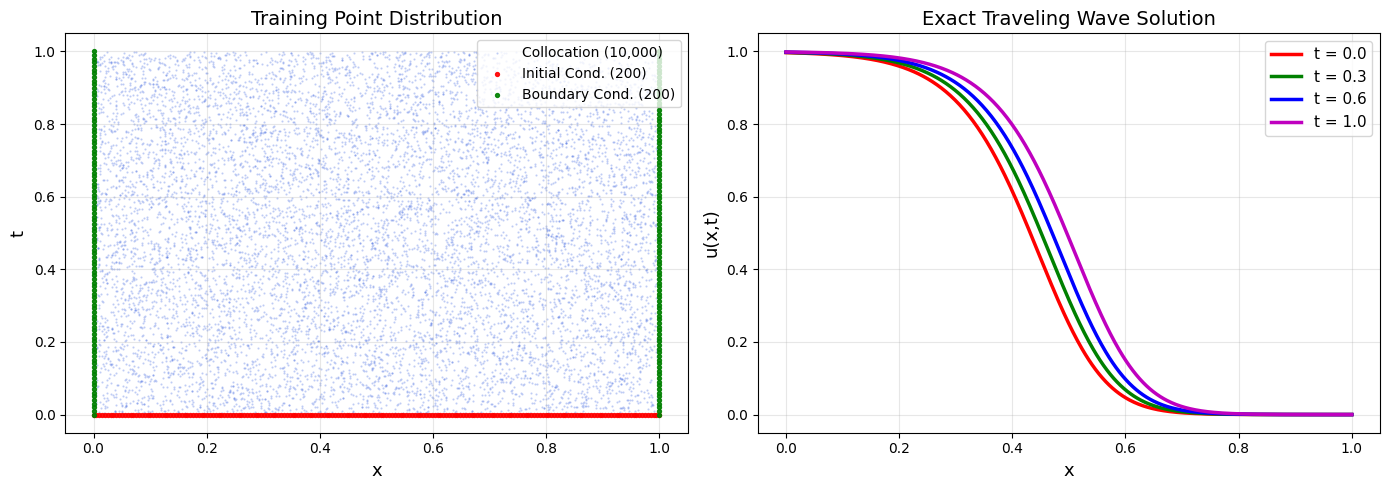

Figure saved: training_points.png


In [9]:
# ── Visualize training data distribution ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: point distribution
ax = axes[0]
ax.scatter(x_pde_np, t_pde_np, s=0.3, c='royalblue',
           alpha=0.3, label=f'Collocation ({N_pde:,})')
ax.scatter(x_ic_np, t_ic_np,   s=8,   c='red',
           alpha=0.9, label=f'Initial Cond. ({N_ic})', zorder=5)
ax.scatter(x_bc_np, t_bc_np_all, s=8, c='green',
           alpha=0.9, label=f'Boundary Cond. ({N_bc})', zorder=5)
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('t', fontsize=13)
ax.set_title('Training Point Distribution', fontsize=14)
ax.legend(loc='upper right', fontsize=10)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)

# Right plot: exact solution at t=0 (initial condition)
ax2 = axes[1]
x_plot = np.linspace(0, 1, 500)
ax2.plot(x_plot, exact_solution(x_plot, 0.0, D, r),
         'r-', lw=2.5, label='t = 0.0')
ax2.plot(x_plot, exact_solution(x_plot, 0.3, D, r),
         'g-', lw=2.5, label='t = 0.3')
ax2.plot(x_plot, exact_solution(x_plot, 0.6, D, r),
         'b-', lw=2.5, label='t = 0.6')
ax2.plot(x_plot, exact_solution(x_plot, 1.0, D, r),
         'm-', lw=2.5, label='t = 1.0')
ax2.set_xlabel('x', fontsize=13)
ax2.set_ylabel('u(x,t)', fontsize=13)
ax2.set_title('Exact Traveling Wave Solution', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig('training_points.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: training_points.png")

In [10]:
# ============================================================
# STEP 9: PINN Loss Function
# ============================================================

def pinn_loss(model, x_pde, t_pde, x_ic, t_ic, u_ic,
              x_bc, t_bc, u_bc, D, r,
              w_pde=1.0, w_ic=10.0, w_bc=10.0):
    """
    Compute the total PINN loss = w_ic*L_ic + w_bc*L_bc + w_pde*L_pde

    The weights (w_ic, w_bc, w_pde) balance the three loss terms.
    Giving higher weight to IC/BC (w=10) is common practice
    because IC/BC are "hard constraints" — the solution must
    satisfy them. The PDE constraint is "softer".

    Parameters
    ----------
    model         : FisherKPP_PINN
    x_pde, t_pde  : collocation points [N_pde, 1], requires_grad=True
    x_ic, t_ic    : IC points [N_ic, 1]
    u_ic          : exact IC values [N_ic, 1]
    x_bc, t_bc    : BC points [N_bc, 1]
    u_bc          : exact BC values [N_bc, 1]
    D, r          : PDE parameters
    w_pde, w_ic, w_bc : loss weights

    Returns
    -------
    loss_total : scalar torch.Tensor (differentiable)
    loss_ic    : scalar (for monitoring)
    loss_bc    : scalar (for monitoring)
    loss_pde   : scalar (for monitoring)
    """

    # ── 1. Initial Condition Loss ──────────────────────────────
    # Predict u at IC points (t=0)
    u_ic_pred = model(x_ic, t_ic)   # shape: [N_ic, 1]

    # MSE between prediction and exact IC
    # torch.mean((a - b)**2) is the MSE formula
    loss_ic = torch.mean((u_ic_pred - u_ic)**2)

    # ── 2. Boundary Condition Loss ─────────────────────────────
    # Predict u at boundary points
    u_bc_pred = model(x_bc, t_bc)   # shape: [N_bc, 1]

    # MSE between prediction and exact BC
    loss_bc = torch.mean((u_bc_pred - u_bc)**2)

    # ── 3. PDE Residual Loss ───────────────────────────────────
    # Compute the PDE residual at collocation points
    # This requires autograd → x_pde, t_pde must have requires_grad=True
    _, f = pde_residual(model, x_pde, t_pde, D, r)

    # MSE of the residual (should be zero everywhere)
    loss_pde = torch.mean(f**2)

    # ── Total Loss ─────────────────────────────────────────────
    # Weighted sum of all three terms
    loss_total = w_ic * loss_ic + w_bc * loss_bc + w_pde * loss_pde

    return loss_total, loss_ic, loss_bc, loss_pde


# ── Test the loss before training ────────────────────────────
# At initialization, loss_ic and loss_bc will be large.
# PDE loss depends on the random network — could be anything.

model.train()
loss_t, l_ic, l_bc, l_pde = pinn_loss(
    model, x_pde, t_pde, x_ic, t_ic, u_ic, x_bc, t_bc, u_bc, D, r
)

print("Loss at initialization (BEFORE training):")
print(f"  L_IC  = {l_ic.item():.6f}")
print(f"  L_BC  = {l_bc.item():.6f}")
print(f"  L_PDE = {l_pde.item():.6f}")
print(f"  L_total = {loss_t.item():.6f}")
print("\n(All losses should decrease substantially during training)")

Loss at initialization (BEFORE training):
  L_IC  = 0.678641
  L_BC  = 0.389965
  L_PDE = 0.891355
  L_total = 11.577414

(All losses should decrease substantially during training)


In [11]:
# ============================================================
# STEP 10 & 11: Training Loop
# ============================================================

# ── Re-initialize a fresh model ───────────────────────────────
torch.manual_seed(42)
model = FisherKPP_PINN().to(device)

# ── Optimizer ─────────────────────────────────────────────────
# Adam with learning rate 1e-3 is standard for PINNs.
# lr=1e-3 means the "step size" in parameter space is 0.001.
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ── Learning rate scheduler ───────────────────────────────────
# Reduce LR by factor 0.5 every 5000 iterations.
# This helps: start with big steps (fast learning),
# then take small steps (fine-tune near the solution).
scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer, step_size=5000, gamma=0.5
)

# ── Training hyperparameters ──────────────────────────────────
N_EPOCHS    = 20000    # total training iterations
PRINT_EVERY = 1000     # print progress every N iterations
SAVE_EVERY  = 100      # save loss history every N iterations

# Loss weights (giving more emphasis to IC/BC enforcement)
W_IC  = 10.0
W_BC  = 10.0
W_PDE = 1.0

# ── History storage ───────────────────────────────────────────
history = {
    'loss_total': [],
    'loss_ic':    [],
    'loss_bc':    [],
    'loss_pde':   [],
    'epoch':      []
}

# ── Training begins ───────────────────────────────────────────
print("=" * 60)
print("         Training Fisher-KPP PINN")
print("=" * 60)
print(f"  Epochs:       {N_EPOCHS:,}")
print(f"  Optimizer:    Adam (lr=1e-3, decay every 5000 steps)")
print(f"  Parameters:   {model.count_parameters():,}")
print(f"  Device:       {device}")
print(f"  Weights:      w_ic={W_IC}, w_bc={W_BC}, w_pde={W_PDE}")
print("=" * 60)

start_time = time.time()

for epoch in range(1, N_EPOCHS + 1):

    # Put model in training mode
    # (enables gradient tracking for all parameters)
    model.train()

    # ── Step 1: Zero all gradients ────────────────────────────
    # PyTorch accumulates gradients by default.
    # We must reset them at the start of EVERY iteration.
    # Otherwise gradients from previous iterations add up.
    optimizer.zero_grad()

    # ── Step 2: Compute the total loss ───────────────────────
    # This calls all three loss terms internally,
    # which in turn calls the neural network forward pass
    # and the autograd derivative computation.
    loss_total, loss_ic, loss_bc, loss_pde = pinn_loss(
        model,
        x_pde, t_pde,   # collocation (requires_grad=True)
        x_ic,  t_ic,  u_ic,
        x_bc,  t_bc,  u_bc,
        D, r,
        w_pde=W_PDE, w_ic=W_IC, w_bc=W_BC
    )

    # ── Step 3: Backward pass ─────────────────────────────────
    # Compute ∂Loss/∂θ for ALL parameters θ in the network.
    # PyTorch traverses the computation graph backwards
    # (backpropagation through time and space).
    loss_total.backward()

    # ── Step 4: Gradient clipping (optional but useful) ───────
    # Prevents exploding gradients — caps gradient norm at 1.0.
    # Especially helpful for deep networks with tanh.
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

    # ── Step 5: Parameter update ──────────────────────────────
    # Adam uses the computed gradients to update all θ.
    # After this step: θ ← θ - lr · Adam_direction
    optimizer.step()

    # ── Step 6: Update learning rate ──────────────────────────
    scheduler.step()

    # ── Save loss history ─────────────────────────────────────
    if epoch % SAVE_EVERY == 0:
        history['epoch'].append(epoch)
        history['loss_total'].append(loss_total.item())
        history['loss_ic'].append(loss_ic.item())
        history['loss_bc'].append(loss_bc.item())
        history['loss_pde'].append(loss_pde.item())

    # ── Print progress ────────────────────────────────────────
    if epoch % PRINT_EVERY == 0:
        elapsed = time.time() - start_time
        lr_now = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:>6,} | "
              f"L_total={loss_total.item():.2e} | "
              f"L_ic={loss_ic.item():.2e} | "
              f"L_bc={loss_bc.item():.2e} | "
              f"L_pde={loss_pde.item():.2e} | "
              f"lr={lr_now:.1e} | "
              f"t={elapsed:.0f}s")

total_time = time.time() - start_time
print("=" * 60)
print(f"Training complete! Total time: {total_time:.1f}s")
print(f"Final total loss: {history['loss_total'][-1]:.2e}")
print("=" * 60)

         Training Fisher-KPP PINN
  Epochs:       20,000
  Optimizer:    Adam (lr=1e-3, decay every 5000 steps)
  Parameters:   15,501
  Device:       cuda
  Weights:      w_ic=10.0, w_bc=10.0, w_pde=1.0
Epoch  1,000 | L_total=6.60e-03 | L_ic=4.23e-04 | L_bc=2.06e-04 | L_pde=3.12e-04 | lr=1.0e-03 | t=14s
Epoch  2,000 | L_total=2.45e-03 | L_ic=1.72e-04 | L_bc=6.09e-05 | L_pde=1.21e-04 | lr=1.0e-03 | t=27s
Epoch  3,000 | L_total=1.80e-03 | L_ic=1.26e-04 | L_bc=4.54e-05 | L_pde=7.97e-05 | lr=1.0e-03 | t=40s
Epoch  4,000 | L_total=8.45e-04 | L_ic=4.62e-05 | L_bc=1.86e-05 | L_pde=1.97e-04 | lr=1.0e-03 | t=53s
Epoch  5,000 | L_total=1.29e-03 | L_ic=1.00e-04 | L_bc=2.56e-05 | L_pde=3.50e-05 | lr=5.0e-04 | t=66s
Epoch  6,000 | L_total=2.68e-06 | L_ic=6.12e-08 | L_bc=8.47e-09 | L_pde=1.99e-06 | lr=5.0e-04 | t=79s
Epoch  7,000 | L_total=1.39e-06 | L_ic=2.72e-08 | L_bc=6.91e-09 | L_pde=1.04e-06 | lr=5.0e-04 | t=92s
Epoch  8,000 | L_total=9.07e-06 | L_ic=6.58e-07 | L_bc=1.34e-07 | L_pde=1.16e-06 |

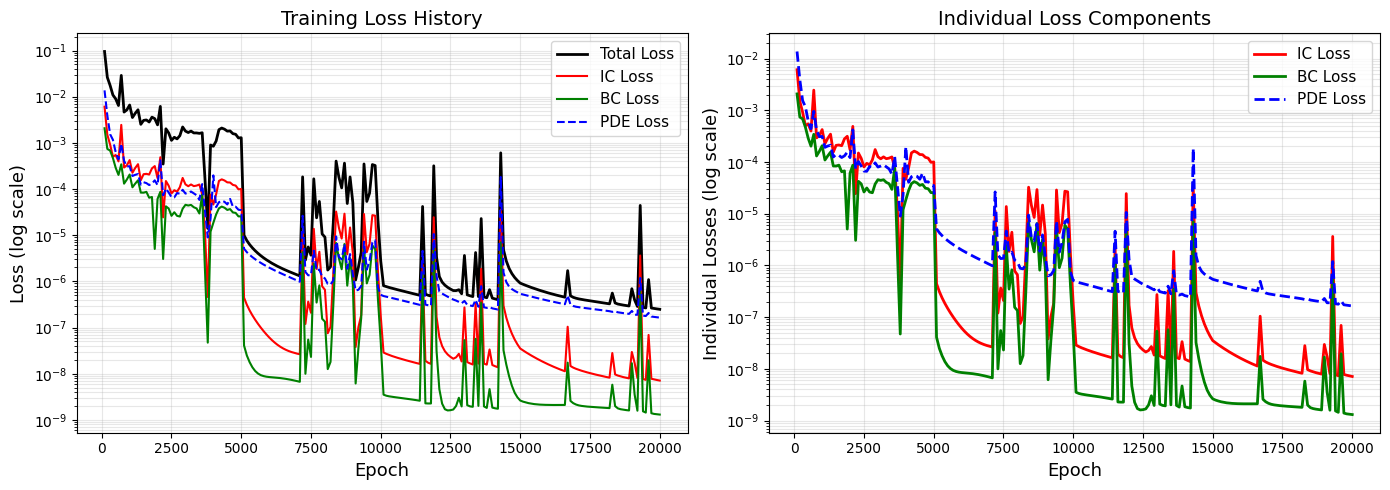

In [12]:
# ── Plot training loss history ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs = history['epoch']

# Left: total loss
ax1 = axes[0]
ax1.semilogy(epochs, history['loss_total'], 'k-',  lw=2,   label='Total Loss')
ax1.semilogy(epochs, history['loss_ic'],    'r-',  lw=1.5, label='IC Loss')
ax1.semilogy(epochs, history['loss_bc'],    'g-',  lw=1.5, label='BC Loss')
ax1.semilogy(epochs, history['loss_pde'],   'b--', lw=1.5, label='PDE Loss')
ax1.set_xlabel('Epoch', fontsize=13)
ax1.set_ylabel('Loss (log scale)', fontsize=13)
ax1.set_title('Training Loss History', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, which='both', alpha=0.3)

# Right: individual losses
ax2 = axes[1]
ax2.semilogy(epochs, history['loss_ic'],  'r-',  lw=2, label='IC Loss')
ax2.semilogy(epochs, history['loss_bc'],  'g-',  lw=2, label='BC Loss')
ax2.semilogy(epochs, history['loss_pde'], 'b--', lw=2, label='PDE Loss')
ax2.set_xlabel('Epoch', fontsize=13)
ax2.set_ylabel('Individual Losses (log scale)', fontsize=13)
ax2.set_title('Individual Loss Components', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig('loss_history.png', dpi=150, bbox_inches='tight')
plt.show()

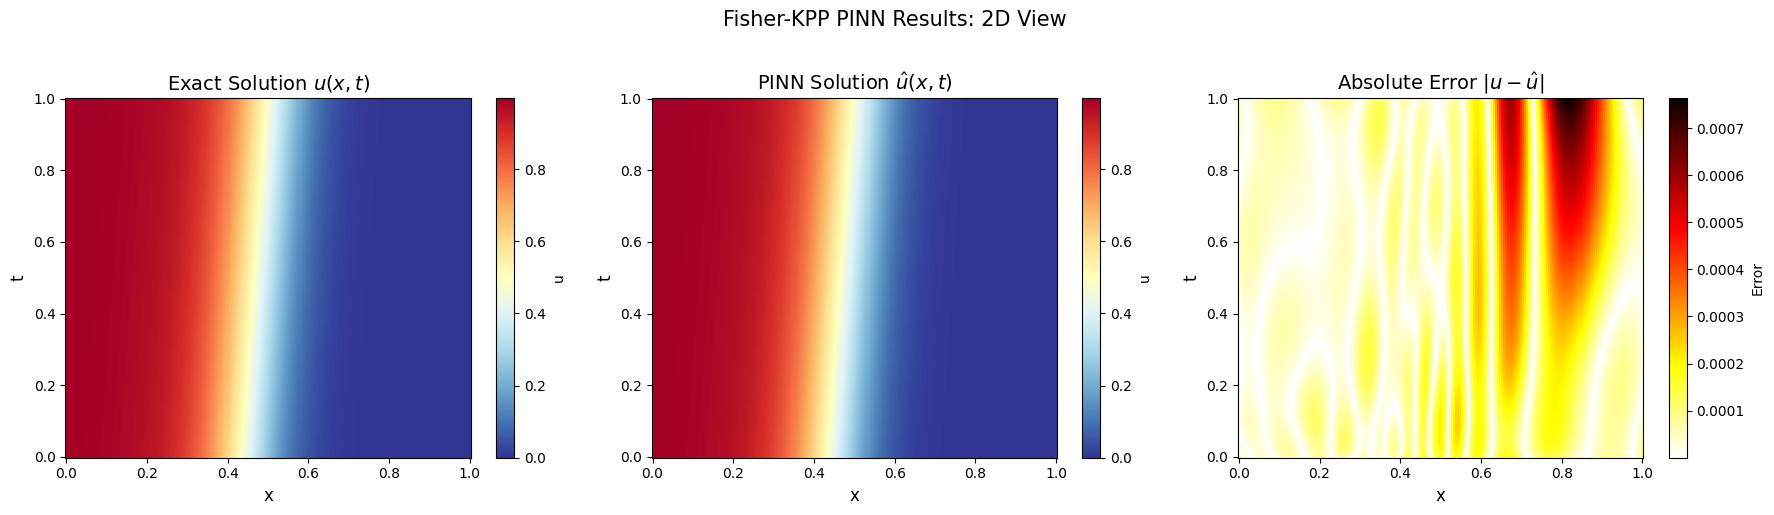

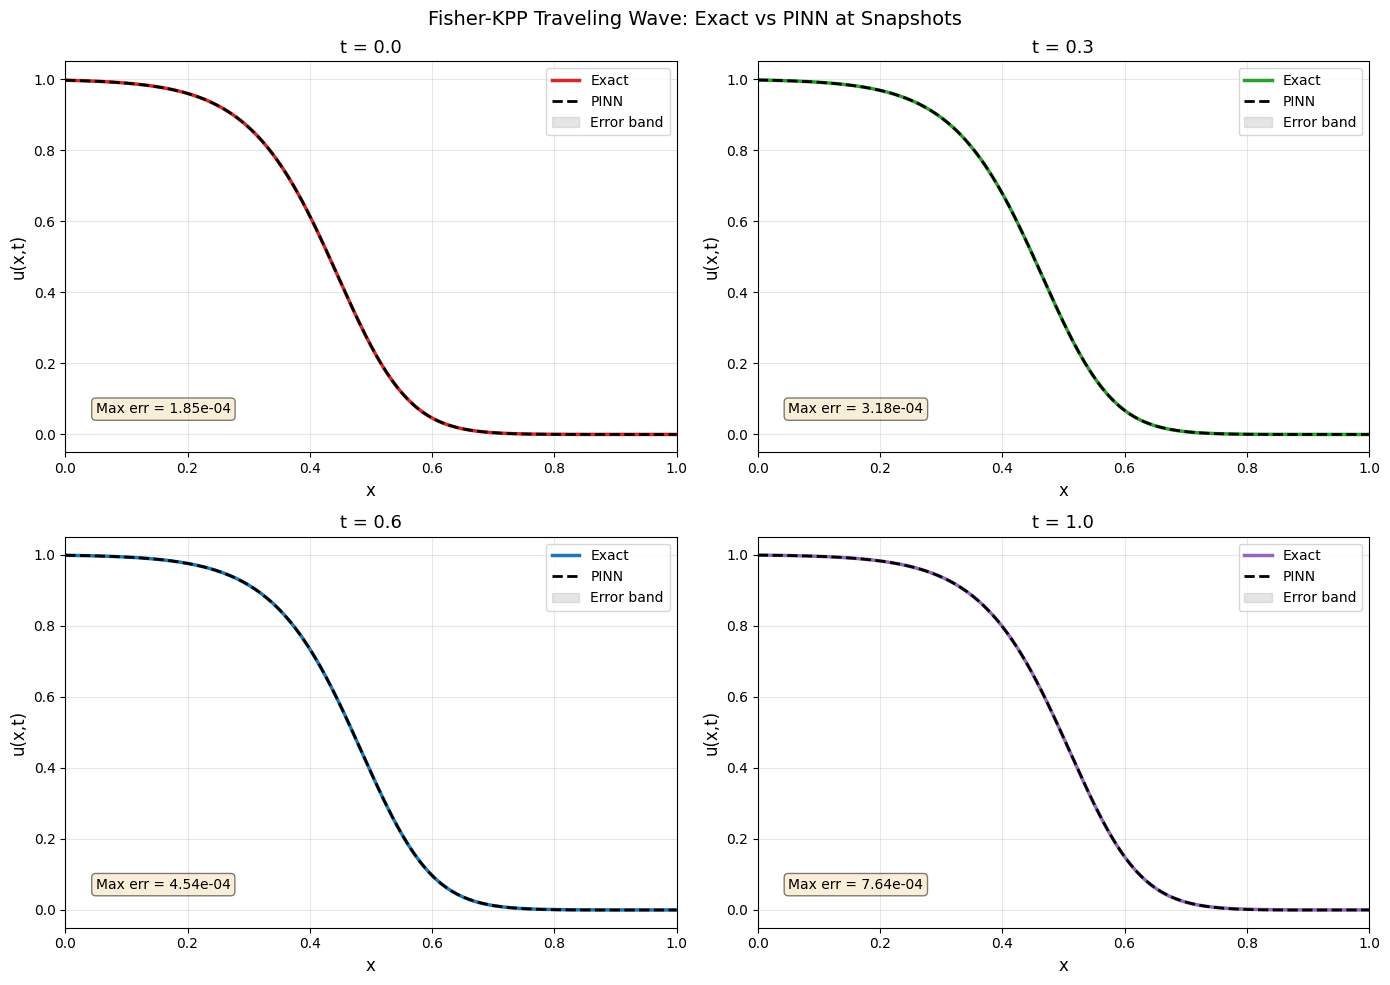

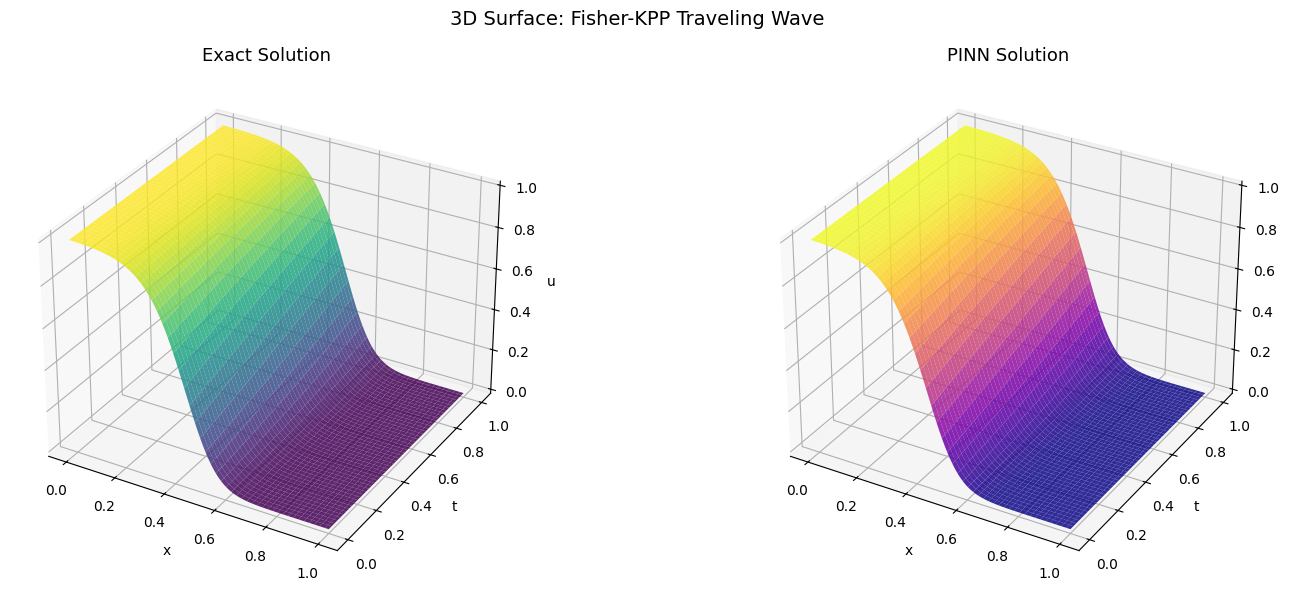

In [13]:
# ============================================================
# STEP 12: Plot Exact vs PINN Solution vs Error
# ============================================================

model.eval()

# ── Create a dense evaluation grid ───────────────────────────
# 200×200 = 40,000 points covering the entire domain
N_plot = 200
x_plot_np = np.linspace(x_min, x_max, N_plot)
t_plot_np = np.linspace(t_min, t_max, N_plot)

# Create a 2D meshgrid
X_plot, T_plot = np.meshgrid(x_plot_np, t_plot_np)
# X_plot, T_plot: each has shape [N_plot, N_plot]

# Flatten for network evaluation
x_flat = X_plot.flatten().reshape(-1, 1)   # [N²,1]
t_flat = T_plot.flatten().reshape(-1, 1)   # [N²,1]

# Convert to tensors (NO requires_grad needed for plotting)
x_tensor = torch.tensor(x_flat, dtype=torch.float32).to(device)
t_tensor = torch.tensor(t_flat, dtype=torch.float32).to(device)

# ── PINN prediction ───────────────────────────────────────────
with torch.no_grad():
    u_pinn_flat = model(x_tensor, t_tensor).cpu().numpy()

# Reshape back to grid
U_pinn = u_pinn_flat.reshape(N_plot, N_plot)

# ── Exact solution ────────────────────────────────────────────
U_exact = exact_solution(X_plot, T_plot, D, r)

# ── Absolute error ────────────────────────────────────────────
U_error = np.abs(U_exact - U_pinn)

# ── Figure 1: 2D Colormaps ────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

vmin = min(U_exact.min(), U_pinn.min())
vmax = max(U_exact.max(), U_pinn.max())

# Exact solution
im0 = axes[0].pcolormesh(X_plot, T_plot, U_exact,
                          cmap='RdYlBu_r', vmin=vmin, vmax=vmax,
                          shading='auto')
axes[0].set_title('Exact Solution $u(x,t)$', fontsize=14)
axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('t', fontsize=12)
plt.colorbar(im0, ax=axes[0], label='u')

# PINN solution
im1 = axes[1].pcolormesh(X_plot, T_plot, U_pinn,
                          cmap='RdYlBu_r', vmin=vmin, vmax=vmax,
                          shading='auto')
axes[1].set_title('PINN Solution $\\hat{u}(x,t)$', fontsize=14)
axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('t', fontsize=12)
plt.colorbar(im1, ax=axes[1], label='u')

# Error
im2 = axes[2].pcolormesh(X_plot, T_plot, U_error,
                          cmap='hot_r', shading='auto')
axes[2].set_title('Absolute Error $|u - \\hat{u}|$', fontsize=14)
axes[2].set_xlabel('x', fontsize=12)
axes[2].set_ylabel('t', fontsize=12)
plt.colorbar(im2, ax=axes[2], label='Error')

plt.suptitle('Fisher-KPP PINN Results: 2D View', fontsize=15, y=1.02)
plt.tight_layout()
plt.savefig('pinn_2d_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 2: Solution slices at fixed times ──────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

t_snapshots = [0.0, 0.3, 0.6, 1.0]
colors_exact = ['#d62728', '#2ca02c', '#1f77b4', '#9467bd']
colors_pinn  = ['#ff7f0e', '#8fbc8f', '#aec7e8', '#c5b0d5']

x_line = np.linspace(x_min, x_max, 500)

for idx, (ax, t_snap) in enumerate(zip(axes.flatten(), t_snapshots)):

    # Exact solution
    u_ex_line = exact_solution(x_line, t_snap, D, r)

    # PINN prediction
    x_t = torch.tensor(x_line.reshape(-1,1),
                        dtype=torch.float32).to(device)
    t_t = torch.full((500, 1), t_snap,
                     dtype=torch.float32).to(device)
    with torch.no_grad():
        u_pinn_line = model(x_t, t_t).cpu().numpy().flatten()

    ax.plot(x_line, u_ex_line,  '-',  lw=2.5,
            color=colors_exact[idx], label='Exact')
    ax.plot(x_line, u_pinn_line, '--', lw=2,
            color='black', label='PINN')

    # Error band
    error_line = np.abs(u_ex_line - u_pinn_line)
    ax.fill_between(x_line,
                    u_pinn_line - error_line,
                    u_pinn_line + error_line,
                    alpha=0.2, color='gray', label='Error band')

    ax.set_title(f't = {t_snap}', fontsize=13)
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('u(x,t)', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.05, 1.05)

    # Annotate max error
    ax.text(0.05, 0.1,
            f'Max err = {error_line.max():.2e}',
            transform=ax.transAxes, fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Fisher-KPP Traveling Wave: Exact vs PINN at Snapshots',
             fontsize=14)
plt.tight_layout()
plt.savefig('pinn_snapshots.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figure 3: 3D surface plot ─────────────────────────────────
fig = plt.figure(figsize=(16, 6))

ax3d1 = fig.add_subplot(121, projection='3d')
surf1 = ax3d1.plot_surface(X_plot, T_plot, U_exact,
                            cmap='viridis', alpha=0.85)
ax3d1.set_title('Exact Solution', fontsize=13)
ax3d1.set_xlabel('x'); ax3d1.set_ylabel('t'); ax3d1.set_zlabel('u')

ax3d2 = fig.add_subplot(122, projection='3d')
surf2 = ax3d2.plot_surface(X_plot, T_plot, U_pinn,
                            cmap='plasma', alpha=0.85)
ax3d2.set_title('PINN Solution', fontsize=13)
ax3d2.set_xlabel('x'); ax3d2.set_ylabel('t'); ax3d2.set_zlabel('u')

plt.suptitle('3D Surface: Fisher-KPP Traveling Wave', fontsize=14)
plt.tight_layout()
plt.savefig('pinn_3d_surface.png', dpi=150, bbox_inches='tight')
plt.show()


  Error Metrics: Overall Domain [0,1]×[0,1]
  MSE             = 3.339141e-08
  RMSE            = 1.827332e-04
  Relative L2     = 2.921834e-04  (0.0292%)
  Max Abs. Error  = 7.645690e-04
  Mean Abs. Error = 1.184353e-04

Error metrics at time snapshots:
    Time |          MSE |         RMSE |     Rel L2
--------------------------------------------------
  t=0.00  |    7.095e-09 |    8.423e-05 |     0.0001
  t=0.25  |    1.268e-08 |    1.126e-04 |     0.0002
  t=0.50  |    2.621e-08 |    1.619e-04 |     0.0003
  t=0.75  |    5.129e-08 |    2.265e-04 |     0.0004
  t=1.00  |    8.588e-08 |    2.931e-04 |     0.0005


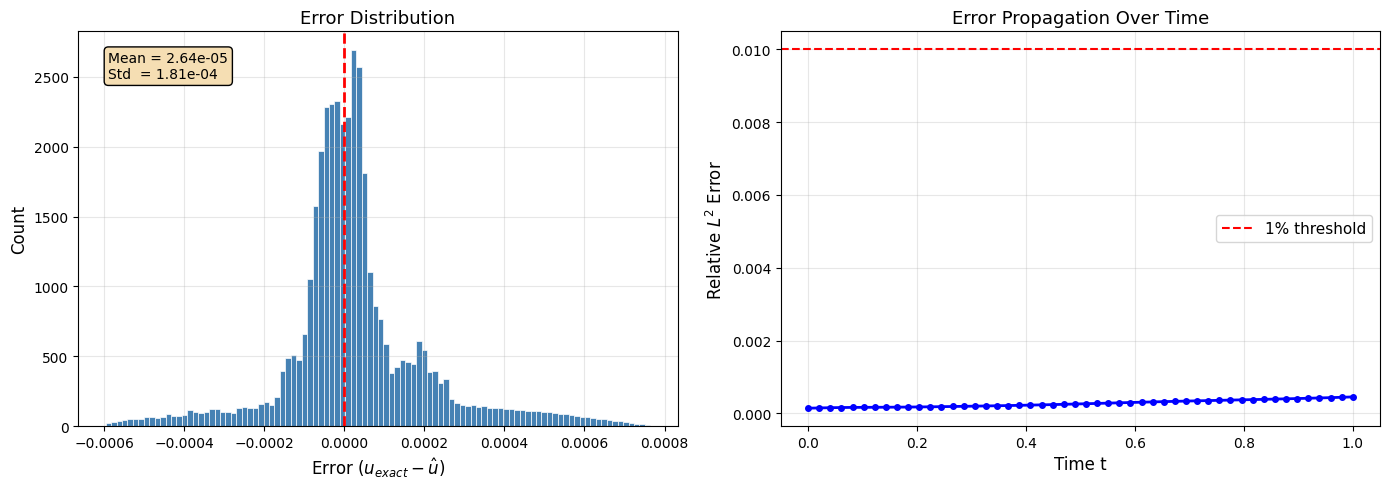


 Summary for Research Paper:
  Total parameters:   15,501
  Training epochs:    20,000
  Training time:      259.0 s
  Overall Rel L2:     0.0292%
  Overall RMSE:       1.8273e-04


In [14]:
# ============================================================
# STEP 13: Error Metrics
# ============================================================

def compute_error_metrics(u_exact, u_pred, label=""):
    """
    Compute MSE, RMSE, and Relative L2 error.

    Parameters
    ----------
    u_exact : numpy array, exact solution
    u_pred  : numpy array, PINN prediction
    label   : string label for printing

    Returns
    -------
    dict with MSE, RMSE, Rel_L2
    """
    # Flatten arrays to 1D
    u_e = u_exact.flatten()
    u_p = u_pred.flatten()

    # Error vector
    error = u_e - u_p

    # MSE: mean of squared errors
    mse = np.mean(error**2)

    # RMSE: root of MSE
    rmse = np.sqrt(mse)

    # Relative L2: ratio of L2 norms
    rel_l2 = np.linalg.norm(error) / np.linalg.norm(u_e)

    # Maximum absolute error
    max_err = np.max(np.abs(error))

    # Mean absolute error
    mae = np.mean(np.abs(error))

    metrics = {
        'MSE':        mse,
        'RMSE':       rmse,
        'Rel_L2':     rel_l2,
        'Max_Error':  max_err,
        'MAE':        mae
    }

    if label:
        print(f"\n{'='*50}")
        print(f"  Error Metrics: {label}")
        print(f"{'='*50}")
        print(f"  MSE             = {mse:.6e}")
        print(f"  RMSE            = {rmse:.6e}")
        print(f"  Relative L2     = {rel_l2:.6e}  ({rel_l2*100:.4f}%)")
        print(f"  Max Abs. Error  = {max_err:.6e}")
        print(f"  Mean Abs. Error = {mae:.6e}")
        print(f"{'='*50}")

    return metrics


# ── Overall metrics ───────────────────────────────────────────
metrics_overall = compute_error_metrics(
    U_exact, U_pinn, label="Overall Domain [0,1]×[0,1]"
)

# ── Metrics at specific time snapshots ────────────────────────
print("\nError metrics at time snapshots:")
print(f"{'Time':>8} | {'MSE':>12} | {'RMSE':>12} | {'Rel L2':>10}")
print("-" * 50)

for t_snap in [0.0, 0.25, 0.5, 0.75, 1.0]:
    # Exact at this time
    u_ex_snap = exact_solution(x_plot_np, t_snap, D, r)

    # PINN at this time
    x_t = torch.tensor(x_plot_np.reshape(-1,1),
                        dtype=torch.float32).to(device)
    t_t = torch.full((N_plot,1), t_snap,
                     dtype=torch.float32).to(device)
    with torch.no_grad():
        u_pinn_snap = model(x_t, t_t).cpu().numpy().flatten()

    m = compute_error_metrics(u_ex_snap, u_pinn_snap)
    print(f"  t={t_snap:.2f}  | {m['MSE']:>12.3e} | "
          f"{m['RMSE']:>12.3e} | {m['Rel_L2']:>10.4f}")


# ── Error distribution plot ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of errors
errors_flat = (U_exact - U_pinn).flatten()
axes[0].hist(errors_flat, bins=100, color='steelblue',
             edgecolor='white', linewidth=0.5)
axes[0].axvline(0, color='red', lw=2, linestyle='--')
axes[0].set_xlabel('Error $(u_{exact} - \\hat{u})$', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Error Distribution', fontsize=13)
axes[0].text(0.05, 0.95,
             f'Mean = {errors_flat.mean():.2e}\n'
             f'Std  = {errors_flat.std():.2e}',
             transform=axes[0].transAxes,
             fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat'))
axes[0].grid(True, alpha=0.3)

# Error vs time
t_arr = np.linspace(t_min, t_max, 50)
rel_l2_vs_t = []
for t_s in t_arr:
    u_ex = exact_solution(x_plot_np, t_s, D, r)
    x_t = torch.tensor(x_plot_np.reshape(-1,1),
                        dtype=torch.float32).to(device)
    t_t = torch.full((N_plot,1), t_s,
                     dtype=torch.float32).to(device)
    with torch.no_grad():
        u_pn = model(x_t, t_t).cpu().numpy().flatten()
    rel_l2_vs_t.append(np.linalg.norm(u_ex-u_pn)/np.linalg.norm(u_ex))

axes[1].plot(t_arr, rel_l2_vs_t, 'b-o', ms=4, lw=2)
axes[1].set_xlabel('Time t', fontsize=12)
axes[1].set_ylabel('Relative $L^2$ Error', fontsize=12)
axes[1].set_title('Error Propagation Over Time', fontsize=13)
axes[1].grid(True, alpha=0.3)
axes[1].axhline(0.01, color='r', ls='--', label='1% threshold')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.savefig('error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n Summary for Research Paper:")
print(f"  Total parameters:   {model.count_parameters():,}")
print(f"  Training epochs:    {N_EPOCHS:,}")
print(f"  Training time:      {total_time:.1f} s")
print(f"  Overall Rel L2:     {metrics_overall['Rel_L2']*100:.4f}%")
print(f"  Overall RMSE:       {metrics_overall['RMSE']:.4e}")

FDM: Nx=200, Nt=2000, dx=0.0050, dt=0.00050
     CFL number = D*dt/dx² = 0.0198  (must be < 0.5 for stability)
     ✓ Stable scheme

  Error Metrics: FDM  at t=1.0
  MSE             = 2.507338e-10
  RMSE            = 1.583458e-05
  Relative L2     = 2.434270e-05  (0.0024%)
  Max Abs. Error  = 4.647805e-05
  Mean Abs. Error = 9.299682e-06

  Error Metrics: PINN at t=1.0
  MSE             = 8.587973e-08
  RMSE            = 2.930524e-04
  Relative L2     = 4.505134e-04  (0.0451%)
  Max Abs. Error  = 7.648075e-04
  Mean Abs. Error = 1.889788e-04


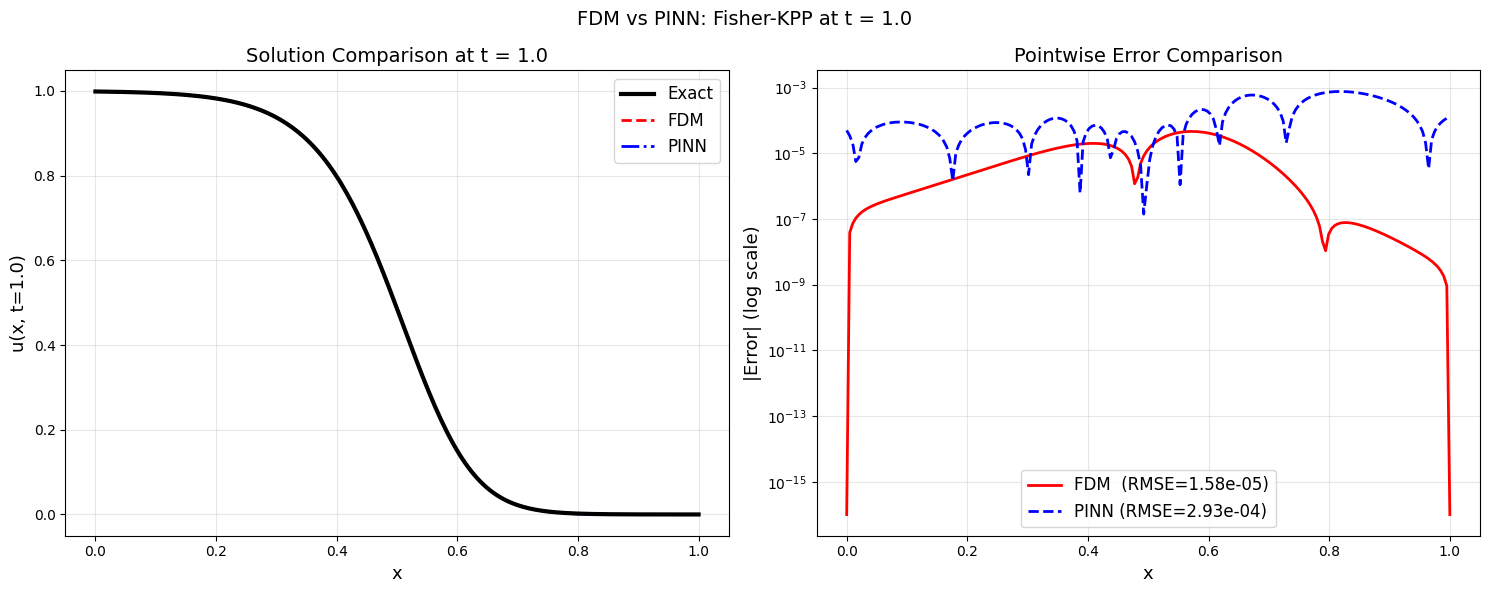


                           Comparison                            
Metric                                     FDM            PINN
-----------------------------------------------------------------
Grid/Param points                 Nx×Nt = 400K     ~15K params
RMSE (t=1.0)                        1.5835e-05      2.9305e-04
Relative L2 (t=1.0)                 2.4343e-05      4.5051e-04
Requires mesh?                             Yes              No
Handles inverse prob?                     Hard            Easy
Higher dimensions?                   Expensive        Feasible
CFL stability constraint?                  Yes              No
Derivative computation            Finite diff.      Exact (AD)


In [15]:
# ============================================================
# STEP 14: FDM Implementation for Comparison
# ============================================================

def solve_fisher_kpp_fdm(D, r, x_min, x_max, t_min, t_max,
                          Nx=200, Nt=2000):
    """
    Solve Fisher-KPP using Explicit Finite Difference Method.

    Discretization:
        du/dt ≈ (u^n_{i} - u^{n-1}_{i}) / Δt          (forward diff)
        d²u/dx² ≈ (u^n_{i+1} - 2u^n_i + u^n_{i-1})/Δx² (central diff)

    Update rule (explicit):
        u^{n+1}_i = u^n_i + Δt * [D*(u^n_{i+1}-2u^n_i+u^n_{i-1})/Δx²
                                   + r*u^n_i*(1-u^n_i)]

    Stability condition (CFL): Δt ≤ Δx²/(2D)

    Parameters
    ----------
    D, r          : PDE parameters
    x_min, x_max  : spatial domain
    t_min, t_max  : temporal domain
    Nx, Nt        : grid points

    Returns
    -------
    x_fdm : spatial grid
    t_fdm : temporal grid
    U_fdm : solution array [Nt, Nx]
    """

    # Grid spacing
    dx = (x_max - x_min) / (Nx - 1)
    dt = (t_max - t_min) / (Nt - 1)

    # CFL stability check
    cfl = D * dt / dx**2
    print(f"FDM: Nx={Nx}, Nt={Nt}, dx={dx:.4f}, dt={dt:.5f}")
    print(f"     CFL number = D*dt/dx² = {cfl:.4f}  (must be < 0.5 for stability)")
    if cfl > 0.5:
        print("     ⚠ WARNING: CFL > 0.5, solution may be UNSTABLE!")
    else:
        print("     ✓ Stable scheme")

    # Grids
    x_fdm = np.linspace(x_min, x_max, Nx)
    t_fdm = np.linspace(t_min, t_max, Nt)

    # Solution storage: U[time_step, space_index]
    U_fdm = np.zeros((Nt, Nx))

    # ── Initial condition ─────────────────────────────────────
    U_fdm[0, :] = exact_solution(x_fdm, 0.0, D, r)

    # ── Boundary conditions (Dirichlet) ───────────────────────
    # Apply at every time step (done inside the loop below)

    # ── Time stepping (explicit Euler) ───────────────────────
    for n in range(Nt - 1):
        u_n = U_fdm[n, :]   # current time level

        # Interior points: i = 1, ..., Nx-2
        # Central difference for diffusion
        diffusion = D * (u_n[2:] - 2*u_n[1:-1] + u_n[:-2]) / dx**2

        # Reaction term (logistic): r*u*(1-u)
        reaction = r * u_n[1:-1] * (1.0 - u_n[1:-1])

        # Explicit update
        U_fdm[n+1, 1:-1] = u_n[1:-1] + dt * (diffusion + reaction)

        # Apply exact boundary conditions
        t_now = t_fdm[n+1]
        U_fdm[n+1, 0]  = exact_solution(np.array([x_fdm[0]]),
                                          t_now, D, r)[0]
        U_fdm[n+1, -1] = exact_solution(np.array([x_fdm[-1]]),
                                          t_now, D, r)[0]

    return x_fdm, t_fdm, U_fdm


# ── Run FDM ──────────────────────────────────────────────────
x_fdm, t_fdm, U_fdm = solve_fisher_kpp_fdm(D, r,
                                             x_min, x_max,
                                             t_min, t_max,
                                             Nx=200, Nt=2000)

# ── Compare at t=1.0 ─────────────────────────────────────────
t_final_idx = -1   # last time step
x_comp = x_fdm
u_exact_final = exact_solution(x_comp, t_fdm[-1], D, r)
u_fdm_final   = U_fdm[t_final_idx, :]

# PINN at same x points and t=1.0
x_comp_tensor = torch.tensor(x_comp.reshape(-1,1),
                               dtype=torch.float32).to(device)
t_comp_tensor = torch.full((len(x_comp),1), t_fdm[-1],
                            dtype=torch.float32).to(device)
with torch.no_grad():
    u_pinn_final = model(x_comp_tensor, t_comp_tensor).cpu().numpy().flatten()

# ── Compute error metrics for both methods ────────────────────
m_fdm  = compute_error_metrics(u_exact_final, u_fdm_final,
                                label="FDM  at t=1.0")
m_pinn = compute_error_metrics(u_exact_final, u_pinn_final,
                                label="PINN at t=1.0")

# ── Comparison plot ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

ax1 = axes[0]
ax1.plot(x_comp, u_exact_final, 'k-',  lw=3,   label='Exact', zorder=5)
ax1.plot(x_comp, u_fdm_final,   'r--', lw=2,   label='FDM')
ax1.plot(x_comp, u_pinn_final,  'b-.',  lw=2,  label='PINN')
ax1.set_xlabel('x', fontsize=13)
ax1.set_ylabel('u(x, t=1.0)', fontsize=13)
ax1.set_title('Solution Comparison at t = 1.0', fontsize=14)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.semilogy(x_comp, np.abs(u_exact_final - u_fdm_final) + 1e-16,
             'r-', lw=2, label=f'FDM  (RMSE={m_fdm["RMSE"]:.2e})')
ax2.semilogy(x_comp, np.abs(u_exact_final - u_pinn_final) + 1e-16,
             'b--', lw=2, label=f'PINN (RMSE={m_pinn["RMSE"]:.2e})')
ax2.set_xlabel('x', fontsize=13)
ax2.set_ylabel('|Error| (log scale)', fontsize=13)
ax2.set_title('Pointwise Error Comparison', fontsize=14)
ax2.legend(fontsize=12)
ax2.grid(True, which='both', alpha=0.3)

plt.suptitle('FDM vs PINN: Fisher-KPP at t = 1.0', fontsize=14)
plt.tight_layout()
plt.savefig('fdm_vs_pinn.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary comparison table ──────────────────────────────────
print("\n" + "="*65)
print(f"{'Comparison':^65}")
print("="*65)
print(f"{'Metric':<30} {'FDM':>15} {'PINN':>15}")
print("-"*65)
print(f"{'Grid/Param points':<30} {'Nx×Nt = 400K':>15} {'~15K params':>15}")
print(f"{'RMSE (t=1.0)':<30} {m_fdm['RMSE']:>15.4e} {m_pinn['RMSE']:>15.4e}")
print(f"{'Relative L2 (t=1.0)':<30} {m_fdm['Rel_L2']:>15.4e} {m_pinn['Rel_L2']:>15.4e}")
print(f"{'Requires mesh?':<30} {'Yes':>15} {'No':>15}")
print(f"{'Handles inverse prob?':<30} {'Hard':>15} {'Easy':>15}")
print(f"{'Higher dimensions?':<30} {'Expensive':>15} {'Feasible':>15}")
print(f"{'CFL stability constraint?':<30} {'Yes':>15} {'No':>15}")
print(f"{'Derivative computation':<30} {'Finite diff.':>15} {'Exact (AD)':>15}")
print("="*65)

In [18]:
# Show all variables currently in memory

for name in globals():
    if not name.startswith("_"):
        print(name)

In
Out
get_ipython
exit
quit
torch
nn
np
plt
device
PINN
gridspec
cm
time
FisherKPP_PINN
model
x_test
t_test
u_pred
N_test
x_batch
t_batch
u_batch
i
compute_derivatives
x_verify
t_verify
x_v
t_v
math
u_v
grads
u_x_v
u_t_v
u_xx_v
u_x_analytical
u_xx_analytical
u_t_analytical
D
r
pde_residual
x_test_pde
t_test_pde
u_test
f_test
x_min
x_max
t_min
t_max
N_pde
N_ic
N_bc
exact_solution
k_val
v_val
x_pde_np
t_pde_np
x_pde
t_pde
x_ic_np
t_ic_np
u_ic_np
x_ic
t_ic
u_ic
N_bc_each
t_bc_np
x_bc_left_np
u_bc_left_np
x_bc_right_np
u_bc_right_np
x_bc_np
t_bc_np_all
u_bc_np
x_bc
t_bc
u_bc
fig
axes
ax
ax2
x_plot
pinn_loss
loss_t
l_ic
l_bc
l_pde
optimizer
scheduler
N_EPOCHS
PRINT_EVERY
SAVE_EVERY
W_IC
W_BC
W_PDE
history
start_time
epoch
loss_total
loss_ic
loss_bc
loss_pde
elapsed
lr_now
total_time
epochs
ax1
N_plot
x_plot_np
t_plot_np
X_plot
T_plot
x_flat
t_flat
x_tensor
t_tensor
u_pinn_flat
U_pinn
U_exact
U_error
vmin
vmax
im0
im1
im2
t_snapshots
colors_exact
colors_pinn
x_line
idx
t_snap
u_ex_line
x_t


In [ ]:
for name, value in list(globals().items()):
    if hasattr(value, "shape"):
        print(name, value.shape)

In [17]:
# ============================================================
# ACCURACY METRICS FOR FISHER-KPP PINN
# ============================================================

import numpy as np

# Relative L2 Error
relative_l2 = np.linalg.norm(U_exact - U_pinn) / np.linalg.norm(U_exact)

# RMSE
rmse = np.sqrt(np.mean((U_exact - U_pinn)**2))

# MAE
mae = np.mean(np.abs(U_exact - U_pinn))

# Maximum Absolute Error
max_error = np.max(np.abs(U_exact - U_pinn))

# Mean Relative Error (%)
mean_relative_error = (
    np.mean(
        np.abs(U_exact - U_pinn) /
        (np.abs(U_exact) + 1e-12)
    ) * 100
)

print("="*60)
print("FISHER-KPP PINN ACCURACY METRICS")
print("="*60)

print(f"Relative L2 Error      : {relative_l2:.6e}")
print(f"RMSE                   : {rmse:.6e}")
print(f"MAE                    : {mae:.6e}")
print(f"Maximum Absolute Error : {max_error:.6e}")
print(f"Mean Relative Error %  : {mean_relative_error:.6f}")

print("="*60)

FISHER-KPP PINN ACCURACY METRICS
Relative L2 Error      : 2.921834e-04
RMSE                   : 1.827332e-04
MAE                    : 1.184353e-04
Maximum Absolute Error : 7.645690e-04
Mean Relative Error %  : 48.940999


Since Fisher-KPP has a long region where the solution is very close to zero, the mean relative percentage error becomes artificially inflated.